In [1]:
import yfinance as yf
import pandas as pd

# Define the tickers and the time period
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-07-01'
end_date = '2025-07-31'

# Download historical data
data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)

# Extract individual dataframes
tsla_df = data['TSLA'].copy()
bnd_df = data['BND'].copy()
spy_df = data['SPY'].copy()

# Optional: Reset index to have 'Date' as a column
tsla_df.reset_index(inplace=True)
bnd_df.reset_index(inplace=True)
spy_df.reset_index(inplace=True)


[*********************100%***********************]  3 of 3 completed


In [3]:
print(tsla_df.head())
print(bnd_df.head())
print(spy_df.head())


Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-07-01  18.073999  18.174667  17.856667  17.943333  17.943333   
1     2015-07-02  18.680000  18.830000  18.220667  18.667999  18.667999   
2     2015-07-06  18.591999  18.779333  18.420000  18.648001  18.648001   
3     2015-07-07  18.333332  18.346666  17.384666  17.858667  17.858667   
4     2015-07-08  17.288000  17.386667  16.954000  16.997334  16.997334   

Price     Volume  
0       31518000  
1      107458500  
2       61828500  
3       91576500  
4       93316500  
Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-07-01  80.870003  81.029999  80.830002  80.900002  60.816727   
1     2015-07-02  81.059998  81.180000  81.059998  81.099998  60.967072   
2     2015-07-06  81.440002  81.440002  81.220001  81.379997  61.177586   
3     2015-07-07  81.690002  81.769997  81.459999  81.459999  61.237686   
4     2015-07-08  81.639999  81.760002  81.559998  81.690002

In [4]:
tsla_df.to_csv("../data/TSLA_data.csv", index=False)
bnd_df.to_csv("../data/BND_data.csv", index=False)
spy_df.to_csv("../data/SPY_data.csv", index=False)


In [5]:
# Check data types and non-null counts
tsla_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2535 non-null   datetime64[ns]
 1   Open       2535 non-null   float64       
 2   High       2535 non-null   float64       
 3   Low        2535 non-null   float64       
 4   Close      2535 non-null   float64       
 5   Adj Close  2535 non-null   float64       
 6   Volume     2535 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 138.8 KB


In [6]:
# Summary statistics
tsla_df.describe()
# Count missing values
tsla_df.isnull().sum()



Price
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

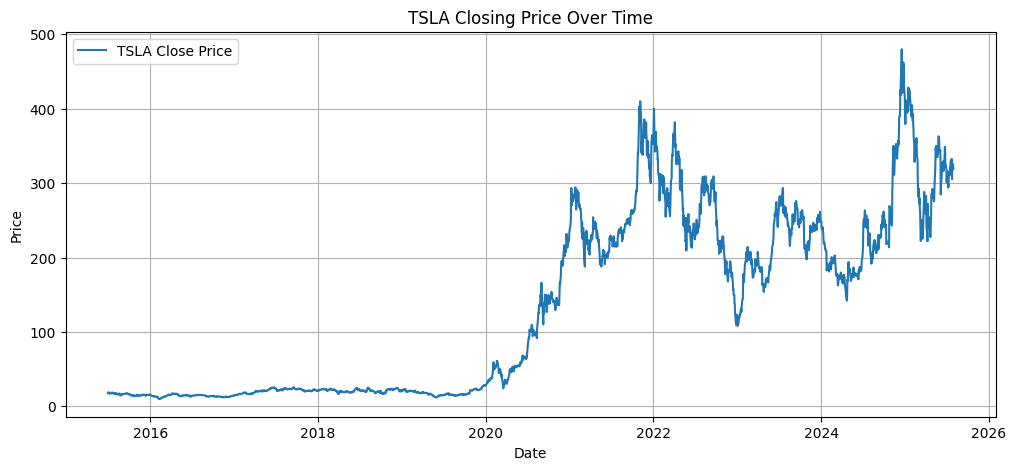

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(tsla_df['Date'], tsla_df['Close'], label='TSLA Close Price')
plt.title('TSLA Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


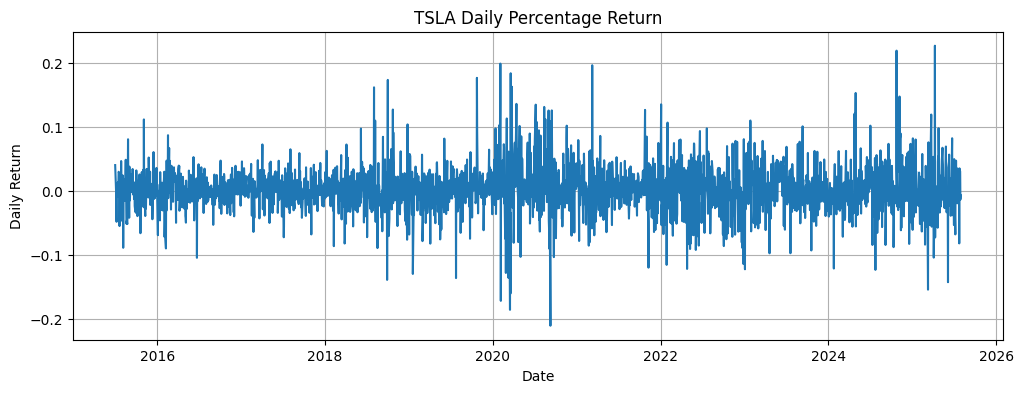

In [8]:
tsla_df['Daily Return'] = tsla_df['Close'].pct_change()

plt.figure(figsize=(12, 4))
plt.plot(tsla_df['Date'], tsla_df['Daily Return'], label='TSLA Daily Return')
plt.title('TSLA Daily Percentage Return')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()


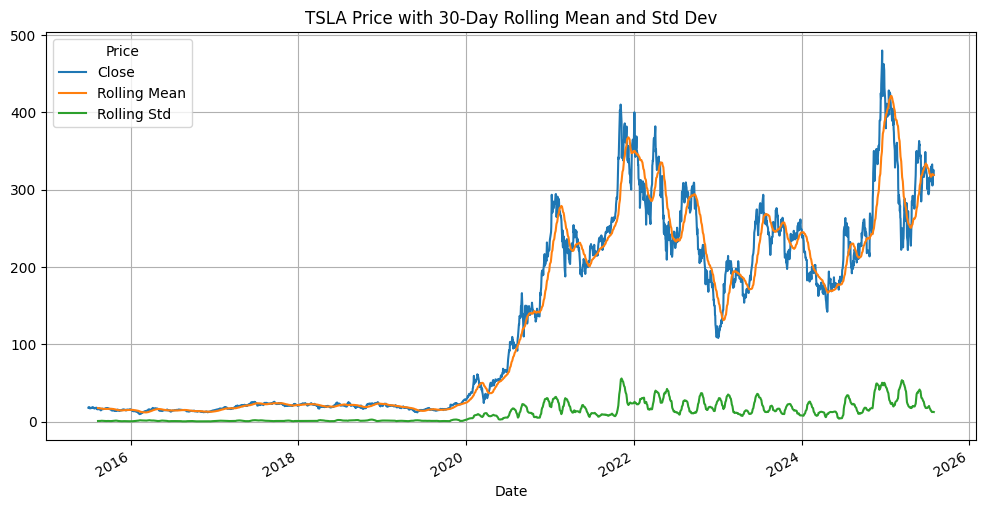

In [9]:
tsla_df['Rolling Mean'] = tsla_df['Close'].rolling(window=30).mean()
tsla_df['Rolling Std'] = tsla_df['Close'].rolling(window=30).std()

tsla_df[['Date', 'Close', 'Rolling Mean', 'Rolling Std']].set_index('Date').plot(figsize=(12, 6))
plt.title('TSLA Price with 30-Day Rolling Mean and Std Dev')
plt.grid(True)
plt.show()


In [10]:
from scipy.stats import zscore

# Create a new column initialized with NaNs
tsla_df['Z-Score'] = float('nan')

# Compute z-scores only on non-NaN Daily Returns and assign back properly
tsla_df.loc[tsla_df['Daily Return'].notna(), 'Z-Score'] = zscore(tsla_df['Daily Return'].dropna())

# Identify outliers: z-score > 3 or < -3
outliers = tsla_df[(tsla_df['Z-Score'] > 3) | (tsla_df['Z-Score'] < -3)]

# Print outlier days
print("Outlier Days (Z-Score > 3 or < -3):")
print(outliers[['Date', 'Daily Return', 'Z-Score']])


Outlier Days (Z-Score > 3 or < -3):
Price       Date  Daily Return   Z-Score
778   2018-08-02      0.161880  4.293466
818   2018-09-28     -0.139015 -3.778190
819   2018-10-01      0.173471  4.604406
835   2018-10-23      0.127189  3.362862
894   2019-01-18     -0.129711 -3.528600
1023  2019-07-25     -0.136137 -3.700979
1087  2019-10-24      0.176692  4.690810
1155  2020-02-03      0.198949  5.287844
1156  2020-02-04      0.137256  3.632924
1157  2020-02-05     -0.171758 -4.656536
1172  2020-02-27     -0.128146 -3.486610
1179  2020-03-09     -0.135725 -3.689931
1182  2020-03-12     -0.116172 -3.165418
1184  2020-03-16     -0.185778 -5.032620
1186  2020-03-18     -0.160344 -4.350341
1187  2020-03-19      0.183877  4.883538
1190  2020-03-24      0.162817  4.318611
1203  2020-04-13      0.136038  3.600250
1261  2020-07-06      0.134794  3.566867
1288  2020-08-12      0.131236  3.471434
1301  2020-08-31      0.125689  3.322625
1306  2020-09-08     -0.210628 -5.699237
1310  2020-09-14     

In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(tsla_df['Close'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -1.4188720053968273
p-value: 0.5731959514207222


c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2140
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6816.645
Date:                Mon, 11 Aug 2025   AIC                          13645.290
Time:                        22:28:54   BIC                          13679.298
Sample:                             0   HQIC                         13657.735
                               - 2140                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0280      0.013     -2.146      0.032      -0.053      -0.002
ar.L2          0.0128      0.011      1.128      0.259      -0.009       0.035
ar.L3         -0.0077      0.014     -0.533      0.5

c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


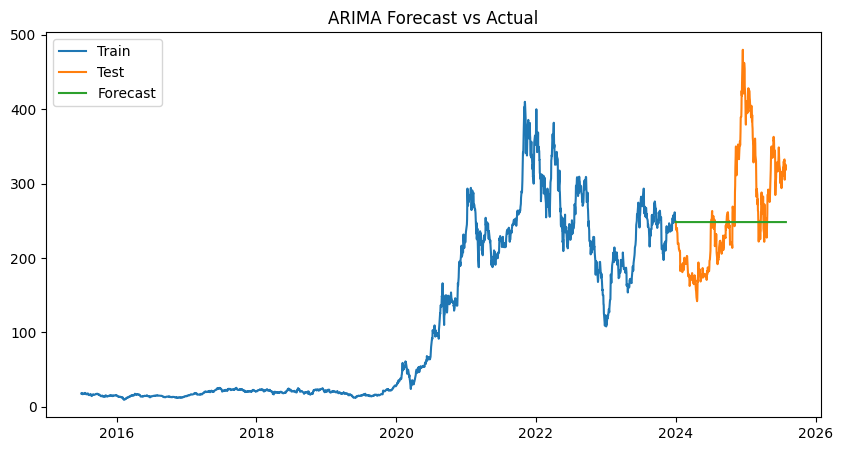

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load data
df = pd.read_csv("../data/TSLA_data.csv", parse_dates=['Date'], index_col='Date')
tsla_close = df['Close']
train = tsla_close[:'2023']
test = tsla_close['2024':]

# Optional: visualize ACF/PACF to help select order
# plot_acf(train); plot_pacf(train); plt.show()

# Manually specify the ARIMA order based on ACF/PACF or trial-and-error
order = (5, 1, 0)  # You can experiment with (p,d,q)

# Fit ARIMA model
model = ARIMA(train, order=order)
model_fit = model.fit()

# Summary
print(model_fit.summary())

# Forecast
forecast_arima = model_fit.forecast(steps=len(test))

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_arima, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()


c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0128 - val_loss: 0.0068
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0014 - val_loss: 0.0048
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0013 - val_loss: 0.0048
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0012 - val_loss: 0.0039
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 9.9576e-04 - val_loss: 0.0032
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 9.8846e-04 - val_loss: 0.0041
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 8.1760e-04 - val_loss: 0.0032
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 7.4985e-04 - val_loss: 0.0025
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 6.9755e-04 - val_loss: 0.0031
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 7.3883e-04 - val_loss: 0.0031
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step


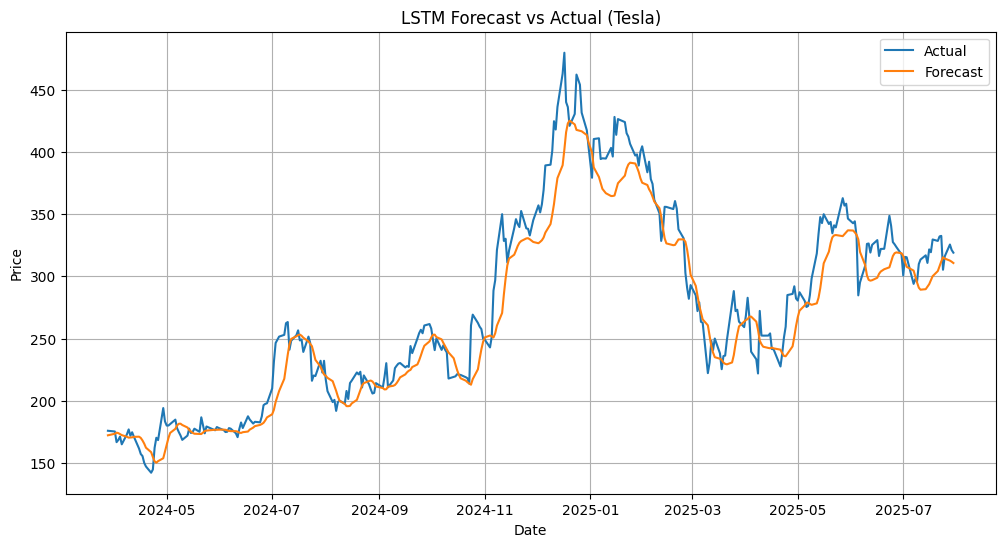

MAE: 16.303271529923624
RMSE: 22.432982840999752
MAPE: 5.65%


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

df = pd.read_csv("../data/TSLA_data.csv", parse_dates=['Date'], index_col='Date')
df = df[['Close']]  # Use 'Close' price for forecasting
df.dropna(inplace=True)

train = df[:'2023']
test = df['2024':]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


def create_sequences(data, seq_length=60):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60  # 60 previous days to predict next day

X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Reshape for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

predictions = model.predict(X_test)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))
plt.figure(figsize=(12,6))
plt.plot(test.index[seq_length:], y_test_unscaled, label="Actual")
plt.plot(test.index[seq_length:], predictions_unscaled, label="Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("LSTM Forecast vs Actual (Tesla)")
plt.legend()
plt.grid(True)
plt.show()


mae = mean_absolute_error(y_test_unscaled, predictions_unscaled)
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100:.2f}%")



In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.optimize import minimize

# Plot style
plt.style.use('seaborn-darkgrid')


# Adjust path if needed
df = pd.read_csv("../data/TSLA_data.csv", parse_dates=['Date'], index_col='Date').sort_index()
df_bnd = pd.read_csv("../data/BND_data.csv", parse_dates=['Date'], index_col='Date').sort_index()
df_spy = pd.read_csv("../data/SPY_data.csv", parse_dates=['Date'], index_col='Date').sort_index()

# Use Adjusted Close if present; fall back to Close
for d in [df, df_bnd, df_spy]:
    if 'Adj Close' in d.columns:
        d['Price'] = d['Adj Close']
    else:
        d['Price'] = d['Close']

tsla = df['Price'].asfreq('B').fillna(method='ffill')
bnd  = df_bnd['Price'].asfreq('B').fillna(method='ffill')
spy  = df_spy['Price'].asfreq('B').fillna(method='ffill')

# Align index: common date range
common_index = tsla.index.intersection(bnd.index).intersection(spy.index)
tsla = tsla.loc[common_index]
bnd  = bnd.loc[common_index]
spy  = spy.loc[common_index]

# Daily log returns (or simple returns)
tsla_ret = tsla.pct_change().dropna()
bnd_ret  = bnd.pct_change().dropna()
spy_ret  = spy.pct_change().dropna()

# Print basic info
print("Data range:", common_index.min(), "to", common_index.max())
print("TSLA rows:", len(tsla))



res = adfuller(tsla.dropna())
print("ADF stat:", res[0], "p-value:", res[1])
# If p-value > 0.05, series is non-stationary → d>=1 (we typically use d=1 for prices)

# Chronological split
train = tsla[:'2023']   # per your setup
test = tsla['2024':]

# You can try a small grid for p and q; d usually 1 for prices
p_range = range(0,6)
d_range = [0,1]
q_range = range(0,4)

best_aic = np.inf
best_order = None
best_model = None

for p in p_range:
    for d in d_range:
        for q in q_range:
            try:
                m = ARIMA(train, order=(p,d,q))
                mf = m.fit()
                if mf.aic < best_aic:
                    best_aic = mf.aic
                    best_order = (p,d,q)
                    best_model = mf
                print(f"Tested ARIMA{(p,d,q)} AIC={mf.aic:.1f}")
            except Exception:
                continue

print("BEST ORDER:", best_order, "AIC:", best_aic)


steps_test = len(test)
forecast_test_res = best_model.get_forecast(steps=steps_test)
forecast_test_mean = forecast_test_res.predicted_mean
forecast_test_ci = forecast_test_res.conf_int(alpha=0.05)

# Align index
forecast_test_mean.index = test.index
forecast_test_ci.index = test.index

# Evaluate
mae = mean_absolute_error(test, forecast_test_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_test_mean))
mape = np.mean(np.abs((test - forecast_test_mean) / test)) * 100

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test MAPE:", f"{mape:.2f}%")


# Fit final model on all available data
final_model = ARIMA(tsla, order=best_order).fit()

horizon_days = 252   # 12 months ~252 trading days; use 126 for 6 months
future_res = final_model.get_forecast(steps=horizon_days)
future_mean = future_res.predicted_mean
future_ci = future_res.conf_int(alpha=0.05)

# build future index (business days)
future_index = pd.date_range(start=tsla.index[-1] + pd.Timedelta(days=1), periods=horizon_days, freq='B')
future_mean.index = future_index
future_ci.index = future_index



plt.figure(figsize=(14,6))
plt.plot(tsla.index, tsla, label='Historical', color='black', linewidth=1)
plt.plot(test.index, test, label='Test (actual)', color='blue', alpha=0.8)
plt.plot(forecast_test_mean.index, forecast_test_mean, label='ARIMA Forecast (test)', color='orange')

# Future forecast
plt.plot(future_index, future_mean, label='ARIMA Forecast (future)', color='green')

# CI shading
plt.fill_between(forecast_test_ci.index, forecast_test_ci.iloc[:,0], forecast_test_ci.iloc[:,1], color='orange', alpha=0.15)
plt.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1], color='green', alpha=0.2)

plt.legend()
plt.title('TSLA — Historical, Test Forecast and 12-month Forecast with 95% CI')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()



OSError: 'seaborn-darkgrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [18]:
future_returns = future_mean.pct_change().dropna()
expected_daily_ret_tsla = future_returns.mean()
expected_annual_ret_tsla = (1 + expected_daily_ret_tsla) ** 252 - 1  # geometric approx

print("Expected daily TSLA return (forecast mean):", expected_daily_ret_tsla)
print("Expected annual TSLA return (from forecast):", expected_annual_ret_tsla)



# use historical daily returns (same common_index used earlier)
mu_bnd_daily = bnd_ret.mean()
mu_spy_daily = spy_ret.mean()

mu_bnd_annual = (1 + mu_bnd_daily) ** 252 - 1
mu_spy_annual = (1 + mu_spy_daily) ** 252 - 1

print("BND annual return (hist):", mu_bnd_annual)
print("SPY annual return (hist):", mu_spy_annual)


# Use overlapping historical daily returns for covariance
returns_df = pd.concat([tsla_ret, bnd_ret, spy_ret], axis=1).dropna()
returns_df.columns = ['TSLA', 'BND', 'SPY']

daily_cov = returns_df.cov()
annual_cov = daily_cov * 252

print("Annualized covariance matrix:\n", annual_cov)
def portfolio_stats(weights, mu_ann, cov_ann, rf=0.0):
    weights = np.array(weights)
    port_ret = np.dot(weights, mu_ann)
    port_vol = np.sqrt(weights.dot(cov_ann).dot(weights))
    sharpe = (port_ret - rf) / port_vol
    return port_ret, port_vol, sharpe



np.random.seed(42)
n_port = 4000
n_assets = 3
results = np.zeros((n_port, 3))  # ret, vol, sharpe
weights_record = []

# expected returns vector (annual)
mu_ann = np.array([expected_annual_ret_tsla, mu_bnd_annual, mu_spy_annual])
cov_ann = annual_cov.values

for i in range(n_port):
    w = np.random.random(n_assets)
    w /= w.sum()
    r, v, s = portfolio_stats(w, mu_ann, cov_ann)
    results[i] = [r, v, s]
    weights_record.append(w)

# plot efficient frontier (approx via random portfolios)
plt.figure(figsize=(8,6))
plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap='viridis', s=8)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Annual Volatility')
plt.ylabel('Annual Return')
plt.title('Random Portfolios (approx. Efficient Frontier)')
plt.show()


# constraints: sum(weights)=1, 0 <= w <= 1 (no shorting)
n = 3
bounds = tuple((0,1) for _ in range(n))
cons = ({'type':'eq', 'fun': lambda w: np.sum(w) - 1})

# minimize volatility
def vol_obj(w):
    return np.sqrt(w.dot(cov_ann).dot(w))

init_w = np.array([1/3]*3)
min_vol_res = minimize(vol_obj, init_w, method='SLSQP', bounds=bounds, constraints=cons)
w_min_vol = min_vol_res.x
r_min, v_min, s_min = portfolio_stats(w_min_vol, mu_ann, cov_ann)
print("Min-vol weights:", w_min_vol, "Return:", r_min, "Vol:", v_min, "Sharpe:", s_min)


rf = 0.0  # set risk-free rate; replace with actual if desired
def neg_sharpe(w):
    r, v, s = portfolio_stats(w, mu_ann, cov_ann, rf)
    return -s

max_sharpe_res = minimize(neg_sharpe, init_w, method='SLSQP', bounds=bounds, constraints=cons)
w_tangency = max_sharpe_res.x
r_tan, v_tan, s_tan = portfolio_stats(w_tangency, mu_ann, cov_ann, rf)
print("Max-Sharpe (tangency) weights:", w_tangency, "Return:", r_tan, "Vol:", v_tan, "Sharpe:", s_tan)


plt.figure(figsize=(8,6))
plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap='viridis', s=8, alpha=0.5)
plt.scatter(v_min, r_min, color='red', marker='*', s=200, label='Min Vol')
plt.scatter(v_tan, r_tan, color='black', marker='X', s=200, label='Max Sharpe')
plt.xlabel('Annual Volatility')
plt.ylabel('Annual Return')
plt.title('Efficient Frontier and Key Portfolios')
plt.legend()
plt.show()

# Format the outputs
assets = ['TSLA','BND','SPY']
print("Minimum Volatility Portfolio:")
for a,w in zip(assets, w_min_vol):
    print(f"  {a}: {w:.2%}")
print(f"  Expected annual return: {r_min:.2%}, Volatility: {v_min:.2%}, Sharpe: {s_min:.2f}")

print("\nMaximum Sharpe (Tangency) Portfolio:")
for a,w in zip(assets, w_tangency):
    print(f"  {a}: {w:.2%}")
print(f"  Expected annual return: {r_tan:.2%}, Volatility: {v_tan:.2%}, Sharpe: {s_tan:.2f}")


NameError: name 'future_mean' is not defined